In [1]:
import os
import matplotlib
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import importlib

from src import eda_process as eda

In [8]:
base_pca = pd.read_excel(
    "../data_processed/base_pca.xlsx"
)

In [9]:
base_pca.shape

(1207, 29)

In [10]:
# Variables que NO entran al PCA
variables_identificacion = [
    "ENTIDAD",
    "MES",
    "AÑO",
    "MES_NUM",
    "FECHA"
]


variables_pca = [
    col for col in base_pca.columns
    if col not in variables_identificacion
]

In [13]:
print("Número de variables para PCA:", len(variables_pca))
print("\nVariables seleccionadas:")
for i, variable in enumerate(variables_pca, start=1):
    print(f"{i:02d}. {variable}")

Número de variables para PCA: 24

Variables seleccionadas:
01. SUFICIENCIA PATRIMONIAL
02. INDICE DE CAPITALIZACION NETO: FK / FI
03. ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS
04. ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO
05. MOROSIDAD DE LA CARTERA TOTAL
06. COBERTURA DE LA CARTERA REFINANCIADA
07. COBERTURA DE LA CARTERA REESTRUCTURADA
08. COBERTURA DE LA CARTERA PROBLEMÁTICA
09. GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)
10. GASTOS DE OPERACION  / MARGEN FINANCIERO
11. GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)
12. RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO
13. RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO
14. CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSITOS A PLAZO)
15. FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO
16. CARTERA REFINANCIADA / CARTERA BRUTA
17. CARTERA REESTRUCTURADA / CARTERA BRUTA
18. VAR_FONDOS DISPONIBLES
19. VAR_INVERSIONES
20. VAR_CARTERA DE CRÉDITOS
21. VAR_TOTAL ACTIVO
22. VAR_Depósitos a la vista
23. VAR_Depósitos a plazo
24. VAR_TOTAL 

In [14]:
X = base_pca[variables_pca].copy()

print("Dimensiones de X:", X.shape)

Dimensiones de X: (1207, 24)


Se obtiene:

$$ X \in \mathbb{R}^{1207\times 24} $$

donde:

$n=1207$ -> número de observaciones banco-año-mes.

$p=24$ -> número de indicadores financieros seleccionados.

In [15]:
nulos_pca = X.isna().sum()

print("Valores nulos por variable:")
print(nulos_pca[nulos_pca > 0])

Valores nulos por variable:
Series([], dtype: int64)


In [16]:
if X.isna().sum().sum() > 0:
    raise ValueError(
        "Existen valores nulos en las variables seleccionadas para PCA. "
        "Debe completarse el tratamiento de valores faltantes antes de continuar."
    )

## 2. Estandarización

In [17]:

X_np = X.to_numpy(dtype=float)

# Media de cada variable
media = np.mean(X_np, axis=0)

# Desviación estándar muestral
desv = np.std(X_np, axis=0, ddof=1)

# Estandarización
Z = (X_np - media) / desv

In [18]:
print("Media aproximada:")
print(np.mean(Z, axis=0))

print("\nDesviación estándar:")
print(np.std(Z, axis=0, ddof=1))

Media aproximada:
[ 0.00000000e+00 -6.47553446e-17 -6.59327145e-16 -1.53058087e-16
 -3.53210971e-17  2.35473980e-17 -1.47171238e-17 -2.94342475e-18
  1.64831786e-16 -3.23776723e-17  2.35473980e-17  1.76605485e-17
  0.00000000e+00 -3.53210971e-17  3.29663573e-16 -3.53210971e-17
  1.41284388e-16 -3.53210971e-17 -2.35473980e-17  1.29510689e-16
  9.41895921e-17  0.00000000e+00 -2.94342475e-18  2.35473980e-17]

Desviación estándar:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 3. SVD

La matriz estandarizada se descompone como:

$$Z=VT$$

Tenemos:

\(U\): vectores singulares izquierdos
\(\Sigma\): valores singulares
\(V^T\): vectores singulares derechos

In [19]:
U, S, Vt = np.linalg.svd(Z,full_matrices=False)

In [20]:
print("Z :", Z.shape)
print("U :", U.shape)
print("S :", S.shape)
print("Vt:", Vt.shape)

Z : (1207, 24)
U : (1207, 24)
S : (24,)
Vt: (24, 24)


## 4. Comprobación de la descomposición

In [21]:
Sigma = np.diag(S)

In [22]:
Z_reconstruida = U @ Sigma @ Vt

In [23]:
error_svd = np.linalg.norm(
    Z - Z_reconstruida
)

print("Error de reconstrucción SVD:", error_svd)

Error de reconstrucción SVD: 5.386617617873712e-13


### 5. Obtención de componentes principales

In [24]:
V = Vt.T

In [25]:
scores = Z @ V

In [26]:
scores

array([[ 1.67034686,  0.50237942, -0.04213426, ..., -0.20979473,
         0.06375347, -0.10005038],
       [-0.11529942,  1.55839498,  0.22466345, ...,  0.10857135,
         0.18918811,  0.10613452],
       [ 1.15617527,  0.9888093 ,  0.02651108, ..., -0.11417886,
         0.28692531, -0.09510934],
       ...,
       [ 1.42494776, -1.54964724, -4.34883016, ...,  0.0312192 ,
        -0.57302182, -0.22250198],
       [-0.05792599,  1.33561538,  0.95966143, ...,  0.30409346,
         0.30136503,  0.07207217],
       [ 0.4483211 , -2.97729132, -0.25494289, ..., -0.37990973,
        -0.0526626 ,  0.13194958]], shape=(1207, 24))

In [27]:
scores_svd = U @ Sigma

In [28]:
error_scores = np.linalg.norm(
    scores - scores_svd
)

print("Error entre ambas formas:", error_scores)

Error entre ambas formas: 4.92599668622584e-13


In [30]:
n_componentes = scores.shape[1]

nombres_componentes = [
    f"PC{i+1}"
    for i in range(n_componentes)
]

df_scores = pd.DataFrame(
    scores,
    columns=nombres_componentes,
    index=base_pca.index
)

In [31]:
df_scores["ENTIDAD"] = base_pca["ENTIDAD"].values
df_scores["AÑO"] = base_pca["AÑO"].values
df_scores["MES"] = base_pca["MES"].values
df_scores["FECHA"] = base_pca["FECHA"].values

In [32]:
df_scores

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC19,PC20,PC21,PC22,PC23,PC24,ENTIDAD,AÑO,MES,FECHA
0,1.670347,0.502379,-0.042134,-0.416447,-0.400394,0.587995,0.064463,0.430966,0.177770,0.118118,...,-0.106883,-0.015775,-0.245932,-0.209795,0.063753,-0.100050,BP GUAYAQUIL,2022,Mayo,2022-05-01
1,-0.115299,1.558395,0.224663,-0.709588,-0.588966,-0.313117,-1.171159,-0.770303,-0.493599,0.053284,...,0.270976,-0.926041,-0.232732,0.108571,0.189188,0.106135,BP PACIFICO,2022,Mayo,2022-05-01
2,1.156175,0.988809,0.026511,-0.498811,-0.637850,1.734359,0.260784,0.023163,0.391043,-0.580411,...,0.064790,0.181011,-0.177315,-0.114179,0.286925,-0.095109,BP PICHINCHA,2022,Mayo,2022-05-01
3,1.640124,0.536628,-0.123792,-0.298277,-0.054033,0.720321,0.466976,0.166415,0.156370,0.035833,...,-0.102165,0.074725,-0.217731,-0.146354,0.015110,-0.132587,BP PRODUBANCO,2022,Mayo,2022-05-01
4,0.613685,1.255829,-0.521423,-0.107043,-0.267869,0.702814,-0.521423,0.085350,0.032167,0.346015,...,0.214881,-0.277597,-0.018935,0.053033,0.148940,-0.127036,BP AUSTRO,2022,Mayo,2022-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,1.036050,0.227408,-1.546625,0.695162,-0.837071,0.741944,0.968608,0.628594,0.188701,1.542611,...,-0.030495,0.075750,0.131641,0.260646,0.103771,-0.138144,BP CAPITAL,2026,Julio,2026-07-01
1203,-2.120454,-2.090060,2.385573,-0.537103,-0.373360,-1.267025,-1.235365,-0.126987,-0.825938,1.035732,...,-0.134286,-0.583872,0.213331,0.524367,0.192741,0.230196,BP DELBANK,2026,Julio,2026-07-01
1204,1.424948,-1.549647,-4.348830,1.904234,-0.426342,0.884789,2.074180,0.699166,0.064172,1.067329,...,0.748695,1.091832,0.154253,0.031219,-0.573022,-0.222502,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,2026,Julio,2026-07-01
1205,-0.057926,1.335615,0.959661,-0.750775,0.050468,0.373882,-0.449840,0.709407,0.316070,-0.246258,...,-0.487957,0.333068,0.564075,0.304093,0.301365,0.072072,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",2026,Julio,2026-07-01


### Varianza explicada y porcentaje

In [33]:
n = Z.shape[0]

varianza_componentes = (S ** 2) / (n - 1)

print(varianza_componentes)

[4.55696798 2.49816155 2.22897973 1.78936504 1.53365593 1.44265175
 1.13631658 1.02747639 0.98832516 0.97728595 0.93065831 0.81563982
 0.75726519 0.63346154 0.56069058 0.49381103 0.45482919 0.34369698
 0.24836566 0.21380777 0.14459937 0.10016026 0.08410619 0.03972204]


In [34]:
varianza_total = np.sum(varianza_componentes)

print("Varianza total:", varianza_total)

Varianza total: 24.000000000000007


In [35]:
print("Número de variables:", Z.shape[1])

Número de variables: 24


In [36]:
porcentaje_varianza = (
    varianza_componentes / varianza_total
) * 100

In [37]:
varianza_acumulada = np.cumsum(porcentaje_varianza)

In [38]:
tabla_varianza = pd.DataFrame({
    "Componente": nombres_componentes,
    "Valor_singular": S,
    "Varianza": varianza_componentes,
    "Porcentaje_varianza": porcentaje_varianza,
    "Varianza_acumulada": varianza_acumulada
})

tabla_varianza

,Componente,Valor_singular,Varianza,Porcentaje_varianza,Varianza_acumulada
0,PC1,74.133011,4.556968,18.987367,18.987367
1,PC2,54.888822,2.498162,10.409006,29.396373
2,PC3,51.847368,2.228980,9.287416,38.683789
3,PC4,46.454001,1.789365,7.455688,46.139476
4,PC5,43.006849,1.533656,6.390233,52.529709
5,PC6,41.711366,1.442652,6.011049,58.540758
6,PC7,37.018884,1.136317,4.734652,63.275411
7,PC8,35.201371,1.027476,4.281152,67.556562
8,PC9,34.524196,0.988325,4.118021,71.674584
9,PC10,34.330844,0.977286,4.072025,75.746609


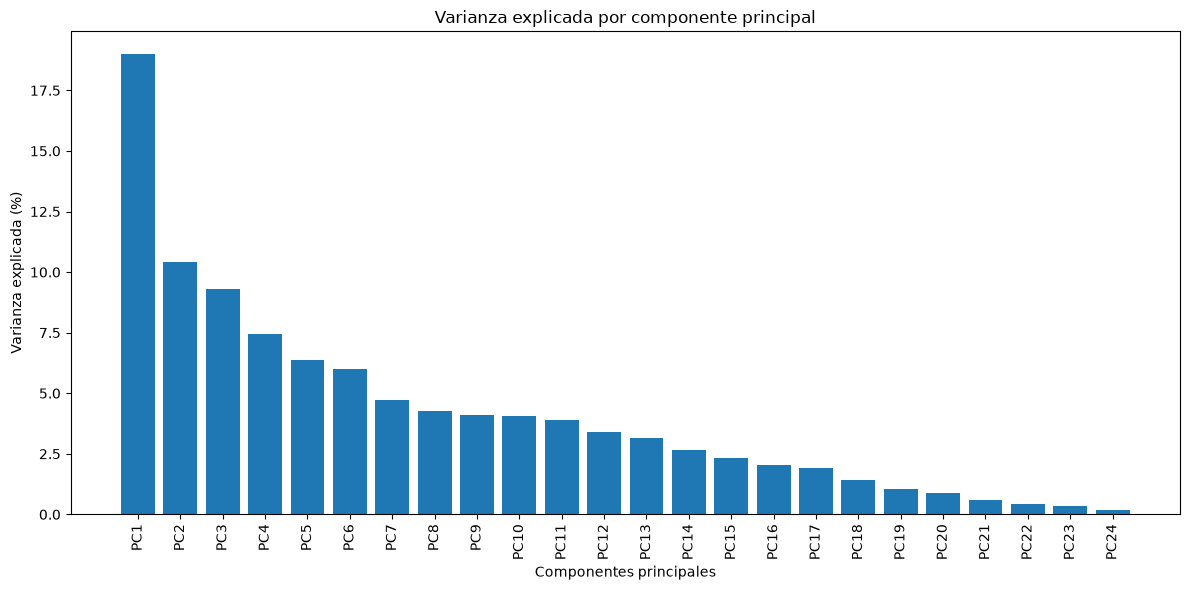

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    nombres_componentes,
    porcentaje_varianza
)

ax.set_xlabel("Componentes principales")
ax.set_ylabel("Varianza explicada (%)")
ax.set_title("Varianza explicada por componente principal")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

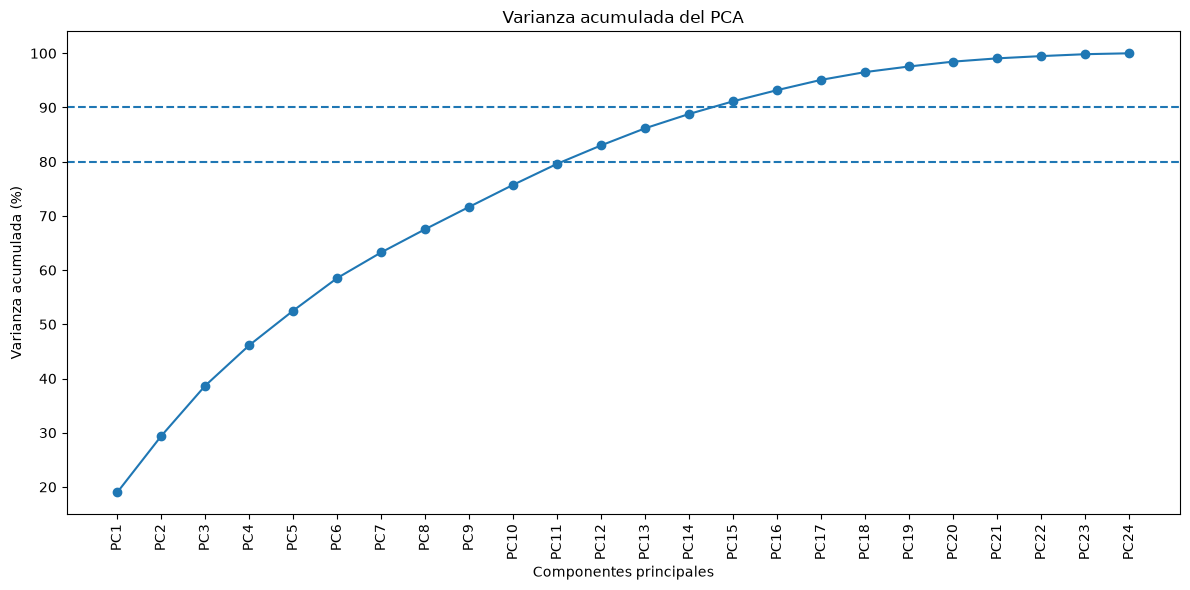

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    nombres_componentes,
    varianza_acumulada,
    marker="o"
)

ax.axhline(
    80,
    linestyle="--"
)

ax.axhline(
    90,
    linestyle="--"
)

ax.set_xlabel("Componentes principales")
ax.set_ylabel("Varianza acumulada (%)")
ax.set_title("Varianza acumulada del PCA")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Cargas y contribución de cada componente

In [41]:
sqrt_lambda = np.sqrt(varianza_componentes)

cargas = V * sqrt_lambda

In [42]:
tabla_cargas = pd.DataFrame(
    cargas,
    index=variables_pca,
    columns=nombres_componentes
)

tabla_cargas

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
SUFICIENCIA PATRIMONIAL,0.038344,-0.004983,0.110517,0.135274,0.006477,-0.115151,-0.091101,-0.179990,0.883019,0.082722,...,-0.025411,-0.011127,0.001741,-0.013969,-0.003576,0.000349,0.000190,0.002968,-0.000339,-0.000506
INDICE DE CAPITALIZACION NETO: FK / FI,-0.344439,-0.620416,0.273715,-0.025754,-0.299957,0.044228,-0.378163,-0.037504,-0.066437,0.078790,...,0.013935,0.193425,-0.217362,-0.141172,0.009791,-0.088269,0.071184,0.139835,0.024185,0.033577
ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,0.291435,-0.298865,0.261488,-0.269791,0.477395,0.193855,0.209807,-0.068644,0.117722,-0.370789,...,0.041294,-0.120877,-0.080247,-0.273687,0.024582,0.144900,0.037361,-0.005922,-0.010500,-0.008283
ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,0.249412,-0.089314,0.402407,0.716901,-0.188680,-0.015504,0.134521,-0.049751,-0.115205,-0.138791,...,-0.045872,-0.078962,0.071299,-0.085717,-0.297387,-0.083999,-0.007025,-0.023731,-0.065471,0.000151
MOROSIDAD DE LA CARTERA TOTAL,-0.851542,0.201430,-0.102377,0.106758,0.117684,0.073877,0.052402,-0.013411,0.028959,-0.022836,...,0.061662,0.051704,0.199025,0.049485,-0.126279,0.163244,0.206879,0.114245,0.009829,-0.019120
COBERTURA DE LA CARTERA REFINANCIADA,0.035699,-0.012935,-0.110673,-0.431330,-0.542525,-0.396146,0.104520,-0.162649,-0.002381,-0.161187,...,-0.039808,0.055234,0.334024,-0.039538,0.003383,0.047565,0.016605,0.003107,-0.007033,-0.001552
COBERTURA DE LA CARTERA REESTRUCTURADA,0.002770,-0.066885,-0.156551,-0.220474,-0.568902,-0.320012,0.310433,-0.142283,0.089483,-0.315601,...,0.071444,-0.060961,-0.232993,0.010797,-0.005876,-0.022368,0.005421,0.007483,0.003421,0.002822
COBERTURA DE LA CARTERA PROBLEMÁTICA,0.275491,-0.002199,0.424015,0.716944,-0.109586,-0.162876,0.073784,-0.065708,-0.098656,-0.114484,...,0.063632,0.061436,0.111542,0.041612,0.325186,0.088958,0.008117,0.028345,0.028411,-0.003233
GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3),-0.766317,-0.521402,0.068106,0.079822,-0.193594,0.129173,-0.072846,0.024458,0.038013,-0.010231,...,-0.043189,0.113627,-0.063103,0.053849,-0.002341,0.078096,-0.060968,-0.098646,-0.003210,-0.141914
GASTOS DE OPERACION / MARGEN FINANCIERO,-0.071653,-0.019983,-0.113070,0.080971,0.052512,-0.170588,-0.335695,0.604354,0.086127,-0.555665,...,-0.039680,-0.018438,-0.008465,-0.007457,0.016376,-0.006896,0.015525,0.004496,-0.007400,0.002979


In [43]:
contribuciones = (V ** 2) * 100

In [44]:
tabla_contribuciones = pd.DataFrame(
    contribuciones,
    index=variables_pca,
    columns=nombres_componentes
)

tabla_contribuciones

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
SUFICIENCIA PATRIMONIAL,0.032265,0.000994,0.547963,1.022661,0.002735,0.919123,0.730385,3.152996,78.893364,0.700192,...,0.115166,0.025074,0.000666,0.056774,0.005149,0.000057,0.000025,0.008794,0.000137,6.458175e-04
INDICE DE CAPITALIZACION NETO: FK / FI,2.603450,15.407967,3.361166,0.037067,5.866646,0.135591,12.585148,0.136892,0.446601,0.635221,...,0.034635,7.576405,10.387644,5.798579,0.038595,3.644092,3.504288,19.522618,0.695436,2.838270e+00
ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,1.863834,3.575435,3.067591,4.067774,14.860309,2.604897,3.873821,0.458598,1.402217,14.067976,...,0.304130,2.958892,1.415808,21.793852,0.243298,9.819984,0.965314,0.035019,0.131088,1.727407e-01
ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,1.365085,0.319316,7.264809,28.722278,2.321248,0.016661,1.592496,0.240901,1.342890,1.971056,...,0.375287,1.262637,1.117675,2.137752,35.608295,3.300108,0.034124,0.562236,5.096508,5.715668e-05
MOROSIDAD DE LA CARTERA TOTAL,15.912424,1.624163,0.470216,0.636939,0.903044,0.378316,0.241653,0.017505,0.084853,0.053362,...,0.678128,0.541354,8.708992,0.712466,6.420479,12.463839,29.598405,13.030924,0.114862,9.203219e-01
COBERTURA DE LA CARTERA REFINANCIADA,0.027966,0.006697,0.549508,10.397311,19.191625,10.877976,0.961397,2.574730,0.000574,2.658526,...,0.282635,0.617799,24.530583,0.454828,0.004609,1.058179,0.190692,0.009639,0.058811,6.065909e-03
COBERTURA DE LA CARTERA REESTRUCTURADA,0.000168,0.179077,1.099524,2.716549,21.103146,7.098563,8.480807,1.970319,0.810178,10.191889,...,0.910341,0.752563,11.935448,0.033919,0.013904,0.234009,0.020325,0.055899,0.013918,2.005102e-02
COBERTURA DE LA CARTERA PROBLEMÁTICA,1.665480,0.000194,8.065981,28.725775,0.783033,1.838887,0.479104,0.420214,0.984798,1.341112,...,0.722150,0.764329,2.735439,0.503803,42.576810,3.701254,0.045564,0.802134,0.959743,2.631380e-02
GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3),12.886679,10.882411,0.208095,0.356080,2.443755,1.156588,0.466997,0.058221,0.146204,0.010711,...,0.332670,2.614565,0.875494,0.843679,0.002206,2.852574,2.570651,9.715474,0.012254,5.070140e+01
GASTOS DE OPERACION / MARGEN FINANCIERO,0.112667,0.015985,0.573573,0.366404,0.179801,2.017133,9.917234,35.547611,0.750551,31.594036,...,0.280817,0.068842,0.015754,0.016178,0.107970,0.022243,0.166677,0.020183,0.065105,2.234324e-02


In [65]:
# Seleccionar únicamente las primeras 15 componentes
contribuciones_15 = tabla_contribuciones.iloc[:, :15]

# Obtener el máximo de cada indicador
max_contribucion = contribuciones_15.max(axis=1)

# Obtener la PC donde se encuentra ese máximo
pc_maxima = contribuciones_15.idxmax(axis=1)

# Construir tabla resumen
resumen_contribuciones = pd.DataFrame({
    "Indicador": contribuciones_15.index,
    "% mayor contribución": max_contribucion,
    "PC con mayor contribución": pc_maxima
})

# Ordenar de mayor a menor contribución
resumen_contribuciones = (
    resumen_contribuciones
    .sort_values("% mayor contribución", ascending=False)
    .reset_index(drop=True)
)

resumen_contribuciones

,Indicador,% mayor contribución,PC con mayor contribución
0,SUFICIENCIA PATRIMONIAL,78.893364,PC9
1,VAR_Depósitos a plazo,75.531170,PC11
2,VAR_TOTAL PATRIMONIO,51.602736,PC13
3,VAR_INVERSIONES,37.396088,PC12
4,CARTERA REESTRUCTURADA / CARTERA BRUTA,35.764533,PC15
5,GASTOS DE OPERACION / MARGEN FINANCIERO,35.547611,PC8
6,COBERTURA DE LA CARTERA REESTRUCTURADA,31.189466,PC14
7,COBERTURA DE LA CARTERA PROBLEMÁTICA,28.725775,PC4
8,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,28.722278,PC4
9,VAR_TOTAL ACTIVO,25.353241,PC3


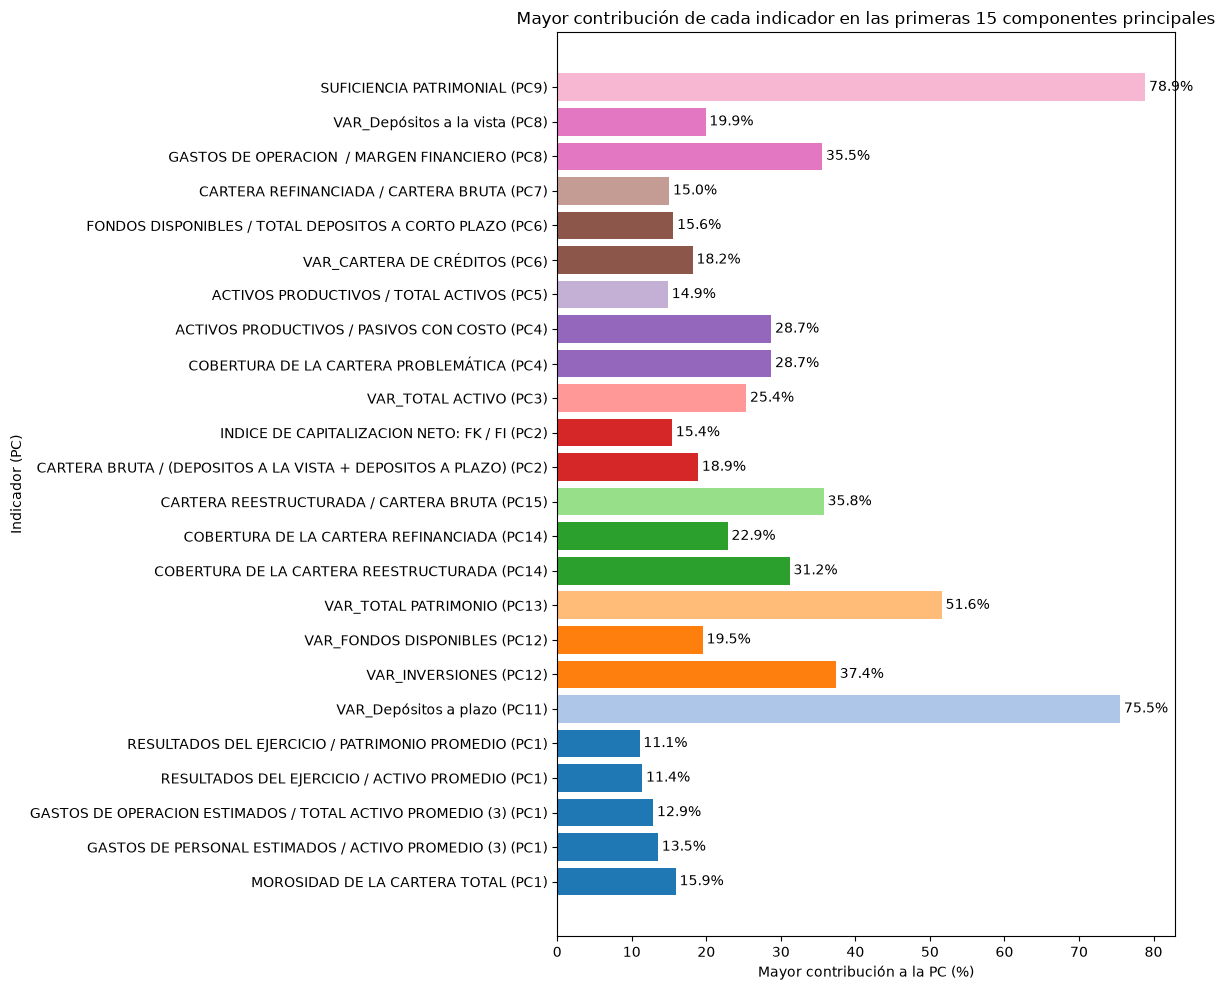

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Copia del resumen
df_grafico = resumen_contribuciones.copy()

# Ordenar por PC y luego por contribución
df_grafico = df_grafico.sort_values(
    ["PC con mayor contribución", "% mayor contribución"],
    ascending=[True, False]
)

# Obtener las PCs presentes
pcs = df_grafico["PC con mayor contribución"].unique()

# Crear una paleta con un color diferente para cada PC
colores = sns.color_palette("tab20", n_colors=len(pcs))

# Diccionario PC -> color
colores_pc = dict(zip(pcs, colores))

# Asignar color a cada barra según su PC
colores_barras = [
    colores_pc[pc]
    for pc in df_grafico["PC con mayor contribución"]
]

plt.figure(figsize=(12, 10))

y_pos = range(len(df_grafico))

plt.barh(
    y_pos,
    df_grafico["% mayor contribución"],
    color=colores_barras
)

# Etiquetas del eje Y
plt.yticks(
    y_pos,
    [
        f"{indicador} ({pc})"
        for indicador, pc in zip(
            df_grafico["Indicador"],
            df_grafico["PC con mayor contribución"]
        )
    ]
)

plt.xlabel("Mayor contribución a la PC (%)")
plt.ylabel("Indicador (PC)")

plt.title(
    "Mayor contribución de cada indicador en las primeras 15 componentes principales"
)

# Porcentaje al final de cada barra
for i, valor in enumerate(df_grafico["% mayor contribución"]):
    plt.text(
        valor + 0.5,
        i,
        f"{valor:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [45]:
print(
    tabla_contribuciones.sum(axis=0)
)

PC1     100.0
PC2     100.0
PC3     100.0
PC4     100.0
PC5     100.0
PC6     100.0
PC7     100.0
PC8     100.0
PC9     100.0
PC10    100.0
PC11    100.0
PC12    100.0
PC13    100.0
PC14    100.0
PC15    100.0
PC16    100.0
PC17    100.0
PC18    100.0
PC19    100.0
PC20    100.0
PC21    100.0
PC22    100.0
PC23    100.0
PC24    100.0
dtype: float64


In [46]:
top_pc1 = (
    tabla_contribuciones["PC1"]
    .sort_values(ascending=False)
    .head(10)
)

print(top_pc1)

MOROSIDAD DE LA CARTERA TOTAL                                15.912424
GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)           13.520394
GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)    12.886679
RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO                   11.413502
RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO               11.051513
CARTERA REFINANCIADA / CARTERA BRUTA                          8.938334
CARTERA REESTRUCTURADA / CARTERA BRUTA                        5.061754
VAR_TOTAL PATRIMONIO                                          4.033688
VAR_CARTERA DE CRÉDITOS                                       3.067274
VAR_TOTAL ACTIVO                                              2.875175
Name: PC1, dtype: float64


In [47]:
for pc in nombres_componentes:
    
    print(f"\n===== {pc} =====")
    
    print(
        tabla_contribuciones[pc]
        .sort_values(ascending=False)
        .head(10)
    )


===== PC1 =====
MOROSIDAD DE LA CARTERA TOTAL                                15.912424
GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)           13.520394
GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)    12.886679
RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO                   11.413502
RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO               11.051513
CARTERA REFINANCIADA / CARTERA BRUTA                          8.938334
CARTERA REESTRUCTURADA / CARTERA BRUTA                        5.061754
VAR_TOTAL PATRIMONIO                                          4.033688
VAR_CARTERA DE CRÉDITOS                                       3.067274
VAR_TOTAL ACTIVO                                              2.875175
Name: PC1, dtype: float64

===== PC2 =====
CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSITOS A PLAZO)    18.899682
INDICE DE CAPITALIZACION NETO: FK / FI                        15.407967
GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)     10.882411
GASTOS DE PERS

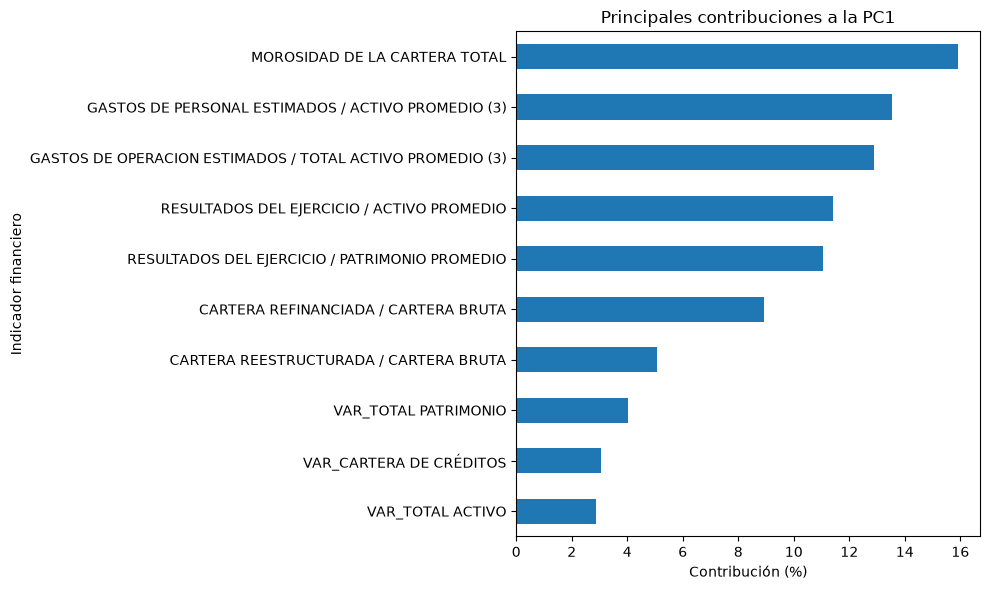

In [48]:
top_pc1 = (
    tabla_contribuciones["PC1"]
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))

top_pc1.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_xlabel("Contribución (%)")
ax.set_ylabel("Indicador financiero")
ax.set_title("Principales contribuciones a la PC1")

plt.tight_layout()
plt.show()

In [50]:
componentes_90 = np.argmax(varianza_acumulada >= 90) + 1

print("Componentes para alcanzar el 90%:", componentes_90)

Componentes para alcanzar el 90%: 15


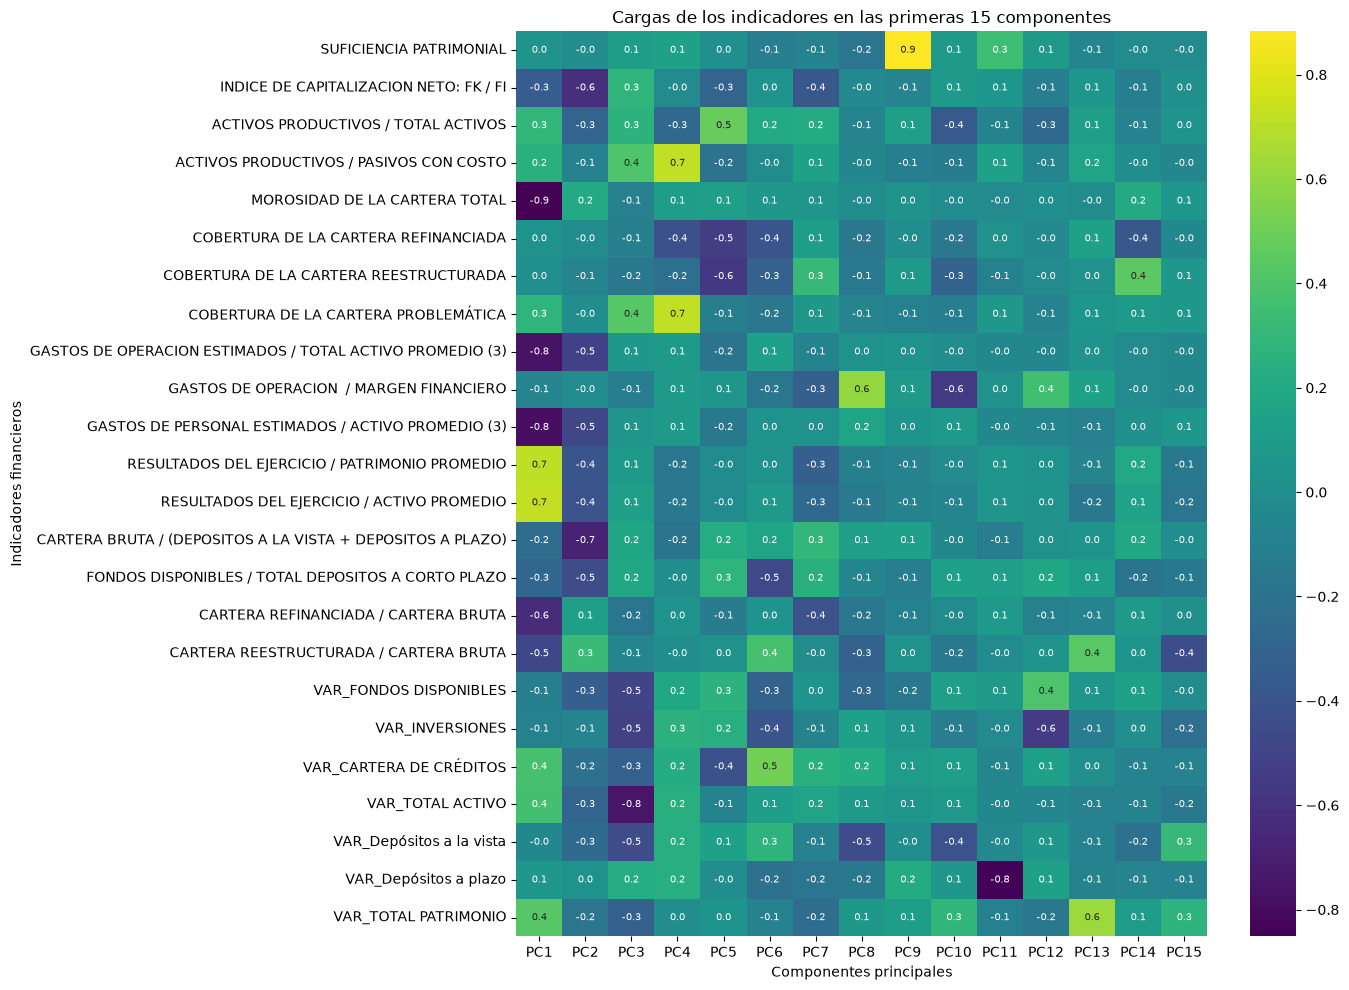

In [ ]:

k = 15

plt.figure(figsize=(14, 10))

sns.heatmap(
    tabla_cargas.iloc[:, :k],
    cmap="viridis",
    annot=True,
    fmt=".1f",
    annot_kws={"size": 7}
)

plt.title(
    f"Cargas de los indicadores en las primeras {k} componentes"
)

plt.xlabel("Componentes principales")
plt.ylabel("Indicadores financieros")

plt.tight_layout()
plt.show()



In [54]:
tabla_contribuciones

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
SUFICIENCIA PATRIMONIAL,0.032265,0.000994,0.547963,1.022661,0.002735,0.919123,0.730385,3.152996,78.893364,0.700192,...,0.115166,0.025074,0.000666,0.056774,0.005149,0.000057,0.000025,0.008794,0.000137,6.458175e-04
INDICE DE CAPITALIZACION NETO: FK / FI,2.603450,15.407967,3.361166,0.037067,5.866646,0.135591,12.585148,0.136892,0.446601,0.635221,...,0.034635,7.576405,10.387644,5.798579,0.038595,3.644092,3.504288,19.522618,0.695436,2.838270e+00
ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,1.863834,3.575435,3.067591,4.067774,14.860309,2.604897,3.873821,0.458598,1.402217,14.067976,...,0.304130,2.958892,1.415808,21.793852,0.243298,9.819984,0.965314,0.035019,0.131088,1.727407e-01
ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,1.365085,0.319316,7.264809,28.722278,2.321248,0.016661,1.592496,0.240901,1.342890,1.971056,...,0.375287,1.262637,1.117675,2.137752,35.608295,3.300108,0.034124,0.562236,5.096508,5.715668e-05
MOROSIDAD DE LA CARTERA TOTAL,15.912424,1.624163,0.470216,0.636939,0.903044,0.378316,0.241653,0.017505,0.084853,0.053362,...,0.678128,0.541354,8.708992,0.712466,6.420479,12.463839,29.598405,13.030924,0.114862,9.203219e-01
COBERTURA DE LA CARTERA REFINANCIADA,0.027966,0.006697,0.549508,10.397311,19.191625,10.877976,0.961397,2.574730,0.000574,2.658526,...,0.282635,0.617799,24.530583,0.454828,0.004609,1.058179,0.190692,0.009639,0.058811,6.065909e-03
COBERTURA DE LA CARTERA REESTRUCTURADA,0.000168,0.179077,1.099524,2.716549,21.103146,7.098563,8.480807,1.970319,0.810178,10.191889,...,0.910341,0.752563,11.935448,0.033919,0.013904,0.234009,0.020325,0.055899,0.013918,2.005102e-02
COBERTURA DE LA CARTERA PROBLEMÁTICA,1.665480,0.000194,8.065981,28.725775,0.783033,1.838887,0.479104,0.420214,0.984798,1.341112,...,0.722150,0.764329,2.735439,0.503803,42.576810,3.701254,0.045564,0.802134,0.959743,2.631380e-02
GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3),12.886679,10.882411,0.208095,0.356080,2.443755,1.156588,0.466997,0.058221,0.146204,0.010711,...,0.332670,2.614565,0.875494,0.843679,0.002206,2.852574,2.570651,9.715474,0.012254,5.070140e+01
GASTOS DE OPERACION / MARGEN FINANCIERO,0.112667,0.015985,0.573573,0.366404,0.179801,2.017133,9.917234,35.547611,0.750551,31.594036,...,0.280817,0.068842,0.015754,0.016178,0.107970,0.022243,0.166677,0.020183,0.065105,2.234324e-02


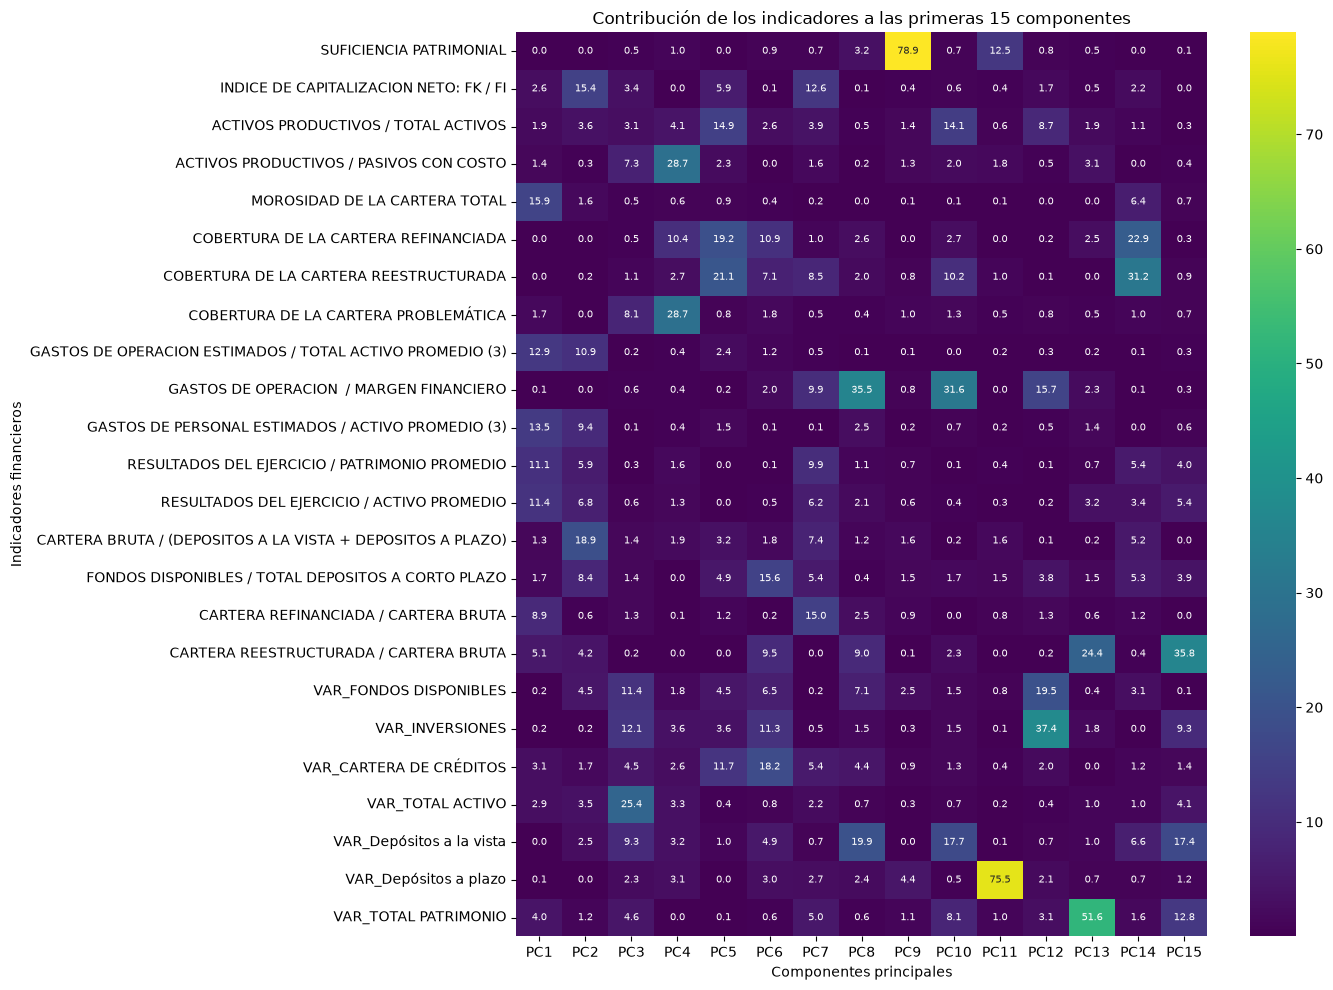

In [55]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    tabla_contribuciones.iloc[:, :componentes_90],
    cmap="viridis",
    annot=True,
    fmt=".1f",
    annot_kws={"size": 7}
)

plt.title(
    f"Contribución de los indicadores a las primeras {componentes_90} componentes"
)

plt.xlabel("Componentes principales")
plt.ylabel("Indicadores financieros")

plt.tight_layout()
plt.show()

El análisis de componentes principales permitió reducir la dimensionalidad del conjunto de 24 indicadores financieros, identificando una estructura de dimensiones latentes que sintetizan diferentes aspectos del comportamiento de las entidades bancarias. Los resultados muestran que las primeras 11 componentes explican aproximadamente el 80% de la varianza total, mientras que las primeras 15 componentes alcanzan aproximadamente el 91%. Esto evidencia que es posible reducir la dimensionalidad de los indicadores originales manteniendo una proporción importante de la información contenida en los datos.

La primera componente concentra aproximadamente el 19% de la varianza y presenta cargas elevadas en indicadores de morosidad, eficiencia operativa y rentabilidad. Por esta estructura, la PC1 puede interpretarse como una dimensión asociada al desempeño financiero integral. A diferencia de algunas componentes posteriores, su contribución se encuentra distribuida entre varios indicadores, lo que indica que representa una dimensión transversal del comportamiento financiero y no un único indicador.

Las componentes posteriores permiten identificar dimensiones más específicas de la estructura financiera. Por ejemplo, la PC9 presenta una contribución predominante de la suficiencia patrimonial, mientras que la PC11 está fuertemente asociada con la variación de los depósitos a plazo. Asimismo, componentes como la PC12, PC13, PC14 y PC15 presentan contribuciones importantes de variables relacionadas con inversiones, patrimonio, cobertura y cartera reestructurada. Esto evidencia que el PCA permite identificar tanto dimensiones financieras generales como patrones específicos presentes en las entidades.

Para la etapa de clustering se utilizarán dos representaciones alternativas del espacio reducido: una conformada por las primeras 11 componentes, que explican aproximadamente el 80% de la varianza, y otra conformada por las primeras 15 componentes, que explican aproximadamente el 91%. Ambas representaciones serán utilizadas como entrada para un modelo de K-Means, con el propósito de evaluar si la incorporación de las componentes adicionales mejora la identificación y separación de los perfiles financieros. La selección de la representación y del número de grupos se realizará mediante múltiples métricas de evaluación del clustering y considerando también la interpretabilidad financiera de los grupos obtenidos.

In [72]:
# Seleccionar identificadores + primeras 11 componentes
columnas_pc11 = [
    "ENTIDAD",
    "AÑO",
    "MES"
] + [f"PC{i}" for i in range(1, 12)]

df_pc11 = df_scores[columnas_pc11].copy()

# Exportar
df_pc11.to_excel(
    "../data_processed/base_pca_pc11.xlsx",
    index=False
)

In [73]:
# Seleccionar identificadores + primeras 15 componentes
columnas_pc15 = [
    "ENTIDAD",
    "AÑO",
    "MES"
] + [f"PC{i}" for i in range(1, 16)]

df_pc15 = df_scores[columnas_pc15].copy()

# Exportar
df_pc15.to_excel(
    "../data_processed/base_pca_pc15.xlsx",
    index=False
)

In [ ]:
Y para interpretar las primeras dimensiones:

PC1 — Desempeño financiero integral

Morosidad + eficiencia + rentabilidad.

PC2 — Intermediación y capitalización

Cartera/depósitos + capitalización.

PC3 — Dinámica de activos

Principalmente crecimiento del activo.

PC4 — Cobertura y productividad de activos

Cobertura problemática + activos productivos/pasivos con costo.

PC5 — Estructura de activos y cobertura

Activos productivos/total + coberturas específicas.

PC6 — Crecimiento de cartera y liquidez

Variación de cartera + fondos disponibles/depósitos.

PC7–PC8

Dimensiones financieras más específicas relacionadas con cartera, depósitos y eficiencia.

PC9–PC15

Dimensiones progresivamente más específicas:

suficiencia patrimonial
depósitos a plazo
inversiones
patrimonio
coberturas
cartera reestructurada

Estas etiquetas son interpretaciones de las cargas, no nombres estadísticos oficiales de las PCs. Para la tesis conviene presentarlas como interpretaciones propuestas.